# **Modeling**

### Imports

In [14]:
import sys
!{sys.executable} -m pip install lightgbm catboost xgboost

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
import os
from sklearn.base import clone
from lightgbm import early_stopping
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import RocCurveDisplay
import lightgbm as lgbm
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (f1_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)

RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed()

In [16]:
X_train = pd.read_parquet('data/X_train_final.parquet')
X_test = pd.read_parquet('data/X_test_final.parquet')
y_train = pd.read_parquet('data/y_train_final.parquet')['isFraud'] 
y_test = pd.read_parquet('data/y_test_final.parquet')['isFraud']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (472432, 238) | Test: (118108, 238)


## XGBoost

In [ ]:
fraud_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=5,
    colsample_bytree=0.8,
    subsample=0.8,
    tree_method='hist',
    scale_pos_weight=fraud_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_state=RANDOM_SEED,
    thread_count=-1,
    verbose=0
)

ensemble_model = StackingClassifier(
    estimators=[
        ('XGBoost', xgb_model),
        ('LightGBM', lgb_model),
        ('CatBoost', cat_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, solver='lbfgs'),
    cv=5,
    n_jobs=-1
)

models_base = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model
}

In [18]:
val_cut = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
y_tr, y_val = y_train.iloc[:val_cut], y_train.iloc[val_cut:]

best_iters = {}

print("--- Base models performance (early-stopped) ---")
for nome, modelo in models_base.items():
    m = clone(modelo)
    if nome == 'XGBoost':
        m.set_params(n_estimators=2000, early_stopping_rounds=50, eval_metric='auc')
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        best_iters[nome] = int(m.best_iteration) + 1
    elif nome == 'LightGBM':
        m.set_params(n_estimators=2000)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
              callbacks=[early_stopping(50, verbose=False)])
        best_iters[nome] = int(m.best_iteration_)
    else:  # CatBoost
        m.set_params(iterations=2000, early_stopping_rounds=50)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        best_iters[nome] = int(m.get_best_iteration()) + 1

    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1]

    print(f"\n[{nome}] best_iter={best_iters[nome]}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print("-" * 40)


xgb_model.set_params(n_estimators=best_iters['XGBoost'])
lgb_model.set_params(n_estimators=best_iters['LightGBM'])
cat_model.set_params(iterations=best_iters['CatBoost'])
print(f"\nTuned iteration counts baked into the ensemble: {best_iters}")

--- Base models performance (early-stopped) ---

[XGBoost] best_iter=187
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    114044
           1       0.27      0.64      0.38      4064

    accuracy                           0.93    118108
   macro avg       0.63      0.79      0.67    118108
weighted avg       0.96      0.93      0.94    118108

ROC-AUC: 0.8855
----------------------------------------
[LightGBM] [Info] Number of positive: 12895, number of negative: 365050
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.220166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31687
[LightGBM] [Info] Number of data points in the train set: 377945, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with p

In [ ]:
y_proba_oof = cross_val_predict(
    ensemble_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# F-beta (beta=2) weights recall twice as much as precision, reflecting the asymmetric
# cost of missing a fraud (financial loss) vs a false block (customer friction)
# Previous: best_f1 = 0 / f1_score(y_train, y_pred_temp)
from sklearn.metrics import fbeta_score
best_threshold = 0.5
best_fbeta = 0

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_temp = (y_proba_oof >= thresh).astype(int)
    fbeta_temp = fbeta_score(y_train, y_pred_temp, beta=2)

    if fbeta_temp > best_fbeta:
        best_fbeta = fbeta_temp
        best_threshold = thresh

print(f"\n Best Threshold (F2): {best_threshold:.2f}")
print(f" Best F2-Score (OOF): {best_fbeta:.4f}")

ensemble_model.fit(X_train, y_train)
y_proba_test = ensemble_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

print(f"\n--- Classification Report (Test Set | Threshold: {best_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC Score (Final): {roc_auc_score(y_test, y_proba_test):.4f}\n")

joblib.dump(ensemble_model, 'data/best_ensemble.pkl')


 Best Threshold (F2): 0.11
 Best F2-Score (OOF): 0.4964

--- Classification Report (Test Set | Threshold: 0.11) ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97    114044
           1       0.34      0.60      0.44      4064

    accuracy                           0.95    118108
   macro avg       0.66      0.78      0.70    118108
weighted avg       0.96      0.95      0.95    118108

ROC-AUC Score (Final): 0.9031



['data/best_ensemble.pkl']

### ROC curves: base models vs. stacking ensemble

ROC-AUC is the project's main metric, so i plot the curves of the three base learners (as fitted *inside* the stacking ensemble, i.e. trained on the full training set) against the final stacking ensemble. The closer a curve hugs the top-left corner, the better the model separates fraud from legitimate transactions; the diagonal is a random classifier (AUC = 0.5).

c:\Users\amand\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


c:\Users\amand\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\amand\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\amand\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


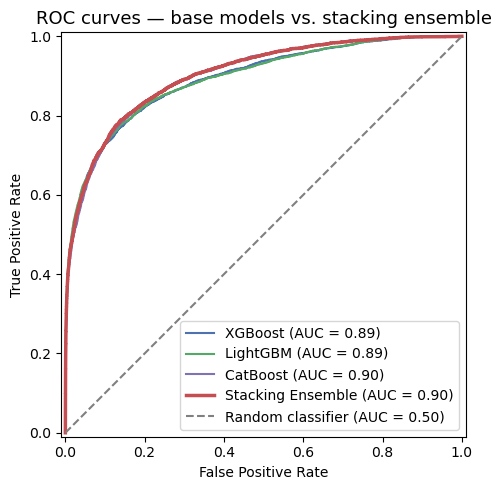

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

# base learners already fitted on the full training set inside the stacking ensemble (no retraining)
base_colors = {'XGBoost': '#4C72B0', 'LightGBM': '#55A868', 'CatBoost': '#8172B3'}
for name, color in base_colors.items():
    est = ensemble_model.named_estimators_[name]
    proba = est.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax, color=color)

# final stacking ensemble (reuse probabilities already computed above)
RocCurveDisplay.from_predictions(y_test, y_proba_test, name='Stacking Ensemble',
                                 ax=ax, color='#C44E52', linewidth=2.5)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC curves — base models vs. stacking ensemble', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

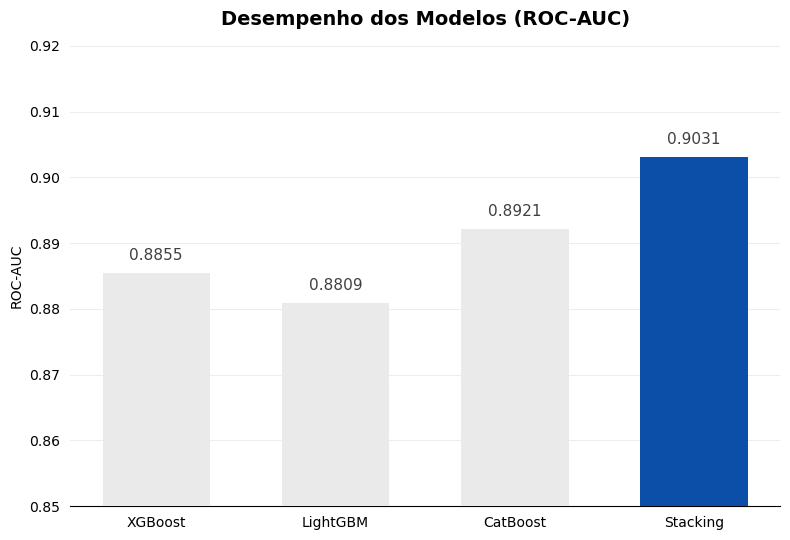

In [21]:
modelos = ["XGBoost", "LightGBM", "CatBoost", "Stacking"]
roc_auc = [0.8855, 0.8809, 0.8921, 0.9031]

COR_DESTAQUE = "#0B4FA8"
COR_BASE = "#EAEAEA"
cores = [COR_BASE, COR_BASE, COR_BASE, COR_DESTAQUE]

fig, ax = plt.subplots(figsize=(8, 5.5))

barras = ax.bar(modelos, roc_auc, color=cores, width=0.6, zorder=3)

for barra, valor in zip(barras, roc_auc):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.0015,
        f"{valor:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#404040",
    )

ax.set_ylim(0.85, 0.92)
ax.set_ylabel("ROC-AUC")
ax.set_title("Desempenho dos Modelos (ROC-AUC)", fontsize=14, weight="bold", pad=15)

ax.grid(axis="y", color="#EDEDED", linewidth=0.75, zorder=0)
ax.grid(axis="x", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()

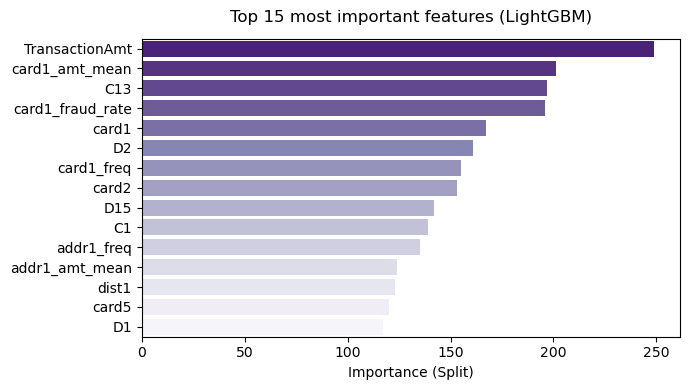

In [22]:
fitted_lgb = ensemble_model.named_estimators_['LightGBM']
importances = fitted_lgb.feature_importances_
features = fitted_lgb.feature_name_

df_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='Purples_r', legend=False)

plt.title('Top 15 most important features (LightGBM)', fontsize=12, pad=12)
plt.xlabel('Importance (Split)', fontsize=10)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [23]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)

dummy_model.fit(X_train, y_train)
y_proba_dummy = dummy_model.predict_proba(X_test)[:, 1]
y_pred_dummy = dummy_model.predict(X_test)

roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)

roc_auc_ensemble = roc_auc_score(y_test, y_proba_test) 

print(f"ROC-AUC Dummy - Baseline: {roc_auc_dummy:.4f}")
print(f"ROC-AUC Ensemble:                  {roc_auc_ensemble:.4f}")
print(f"Learning Gain:      +{(roc_auc_ensemble - roc_auc_dummy):.4f} pontos")
print(f"\nDummy F1-Score:                 {f1_dummy:.4f}")

ROC-AUC Dummy - Baseline: 0.5010
ROC-AUC Ensemble:                  0.9031
Learning Gain:      +0.4020 pontos

Dummy F1-Score:                 0.0363


In [24]:
models_dir = 'data/'
joblib.dump(xgb_model, os.path.join(models_dir, 'xgb_model.pkl'))
joblib.dump(lgb_model, os.path.join(models_dir, 'lgb_model.pkl'))
joblib.dump(cat_model, os.path.join(models_dir, 'cat_model.pkl'))
joblib.dump(ensemble_model, os.path.join(models_dir, 'ensemble_model.pkl'))

model_metadata = {
    'best_threshold': best_threshold,
    'best_fbeta_validation': best_fbeta,
    'timestamp': pd.Timestamp.now(),
    'oof_roc_auc': roc_auc_score(y_train, y_proba_oof),
    'test_roc_auc': roc_auc_score(y_test, y_proba_test),
    'base_model_iterations': best_iters,
}

joblib.dump(model_metadata, os.path.join(models_dir, 'model_metadata.pkl'))
print(model_metadata)

{'best_threshold': np.float64(0.11000000000000001), 'best_fbeta_validation': 0.4964363544485035, 'timestamp': Timestamp('2026-06-23 23:06:33.978805'), 'oof_roc_auc': 0.8830947721235656, 'test_roc_auc': 0.9030646640355967, 'base_model_iterations': {'XGBoost': 187, 'LightGBM': 270, 'CatBoost': 292}}
